In [1]:
import pm4py
import pandas as pd
from pm4py.objects.log.importer.xes import importer as xes_importer
from collections import Counter
import Functions as fk
import numpy as np
import json


from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_pinball_loss

In [2]:
log = xes_importer.apply("/Users/simonimmler/PycharmProjects/Praktikum/data/BPI Challenge 2017.xes")

parsing log, completed traces ::   0%|          | 0/31509 [00:00<?, ?it/s]

# Basic Analytics: 

In [3]:
ts = [e["time:timestamp"] for t in log for e in t if "time:timestamp" in e]
ts = pd.to_datetime(ts, utc=True, errors="coerce")
print("missing ts:", ts.isna().sum())
print("min ts:", ts.min())

print("max ts:", ts.max())

missing ts: 0
min ts: 2016-01-01 09:51:15.304000+00:00
max ts: 2017-02-01 14:11:03.499000+00:00



Different Lifecycle states

In [4]:
lcs = [e.get("lifecycle:transition", "missing") for t in log for e in t]
print(Counter(lcs).most_common(10))

[('complete', 475306), ('suspend', 215402), ('schedule', 149104), ('start', 128227), ('resume', 127160), ('ate_abort', 85224), ('withdraw', 21844)]


In [5]:
df = pm4py.convert_to_dataframe(log)
cols = df["lifecycle:transition"].dropna().unique()
cols

array(['complete', 'schedule', 'withdraw', 'start', 'suspend',
       'ate_abort', 'resume'], dtype=object)

In [6]:
states_per_act = (
    df.groupby("concept:name")["lifecycle:transition"]
      .apply(lambda s: sorted(set(s.dropna())))
      .reset_index(name="lifecycle_states")
)
states_per_act


,concept:name,lifecycle_states
0,A_Accepted,[complete]
1,A_Cancelled,[complete]
2,A_Complete,[complete]
3,A_Concept,[complete]
4,A_Create Application,[complete]
5,A_Denied,[complete]
6,A_Incomplete,[complete]
7,A_Pending,[complete]
8,A_Submitted,[complete]
9,A_Validating,[complete]


Calculate the Event duration for each trace (I use the total span time for each activtiy meaning the total processing time is (timestamp last occurrence in the trace) - (timestamp first occurence in the trace) 

In [7]:
span = (df.dropna(subset=["time:timestamp"]).groupby(["case:concept:name", "concept:name"])["time:timestamp"].agg(act_first_ts="min", act_last_ts="max").reset_index())
span["act_duration_seconds"] = (span["act_last_ts"] - span["act_first_ts"]).dt.total_seconds()

# merge for each Application (case:concept:name) and for each Activity of that case (concept:name)
df_dur = df.merge(span, on=["case:concept:name", "concept:name"], how="left")
df_dur.head(20)

,Action,org:resource,concept:name,EventOrigin,EventID,lifecycle:transition,time:timestamp,case:LoanGoal,case:ApplicationType,case:concept:name,...,NumberOfTerms,Accepted,MonthlyCost,Selected,CreditScore,OfferedAmount,OfferID,act_first_ts,act_last_ts,act_duration_seconds
0,Created,User_1,A_Create Application,Application,Application_652823628,complete,2016-01-01 09:51:15.304000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.304000+00:00,2016-01-01 09:51:15.304000+00:00,0.000
1,statechange,User_1,A_Submitted,Application,ApplState_1582051990,complete,2016-01-01 09:51:15.352000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.352000+00:00,2016-01-01 09:51:15.352000+00:00,0.000
2,Created,User_1,W_Handle leads,Workflow,Workitem_1298499574,schedule,2016-01-01 09:51:15.774000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.774000+00:00,2016-01-01 09:52:36.392000+00:00,80.618
3,Deleted,User_1,W_Handle leads,Workflow,Workitem_1673366067,withdraw,2016-01-01 09:52:36.392000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:51:15.774000+00:00,2016-01-01 09:52:36.392000+00:00,80.618
4,Created,User_1,W_Complete application,Workflow,Workitem_1493664571,schedule,2016-01-01 09:52:36.403000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.403000+00:00,2016-01-02 11:30:28.621000+00:00,92272.218
5,statechange,User_1,A_Concept,Application,ApplState_642383566,complete,2016-01-01 09:52:36.413000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.413000+00:00,2016-01-01 09:52:36.413000+00:00,0.000
6,Obtained,User_17,W_Complete application,Workflow,Workitem_1875340971,start,2016-01-02 10:45:22.429000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.403000+00:00,2016-01-02 11:30:28.621000+00:00,92272.218
7,Released,User_17,W_Complete application,Workflow,Workitem_1452291795,suspend,2016-01-02 10:49:28.816000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-01 09:52:36.403000+00:00,2016-01-02 11:30:28.621000+00:00,92272.218
8,statechange,User_52,A_Accepted,Application,ApplState_99568828,complete,2016-01-02 11:23:04.299000+00:00,Existing loan takeover,New credit,Application_652823628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016-01-02 11:23:04.299000+00:00,2016-01-02 11:23:04.299000+00:00,0.000
9,Created,User_52,O_Create Offer,Offer,Offer_148581083,complete,2016-01-02 11:29:03.994000+00:00,Existing loan takeover,New credit,Application_652823628,...,44.0,True,498.29,True,979.0,20000.0,NaN,2016-01-02 11:29:03.994000+00:00,2016-01-02 11:29:03.994000+00:00,0.000


# Processing Times for W_ Activities

Calculate the processing times for all activities, that have more than 1 lifecycle transitions  -> all others have no real working time

In [8]:
from processing_times.basic_analysis import (
    build_segments_and_instances, build_instance_times,
    add_occurrence_features, add_time_features
)

seg, proc_inst = build_segments_and_instances(df, workflow_only=True)
inst = build_instance_times(seg, proc_inst)

inst = add_occurrence_features(inst)          # -> occ_idx, occ_log
inst = add_time_features(inst, ts_col="inst_start")  # -> tod_sin, tod_cos, weekday


In [9]:
inst[inst["concept:name"]=="W_Assess potential fraud"]["proc_seconds"].describe()


count       324.000000
mean       8035.435398
std       16924.623661
min           3.903000
25%          92.438500
50%         684.986000
75%        5861.768500
max      122669.588000
Name: proc_seconds, dtype: float64

Are there any traces that have actually multiple loops from start - complete

In [10]:
inst.groupby(["concept:name"])["instance"].max().sort_values(ascending=False)


concept:name
W_Validate application      8
W_Call incomplete files     6
W_Assess potential fraud    2
W_Call after offers         2
W_Complete application      2
W_Handle leads              2
Name: instance, dtype: int64

Note: I only use this duration because our simulator does only include lifecycle transitions of start and complete. If i would only use the "real" processing times the durations would be too small

In [11]:
durations_full = {}
durations_total = {}
durations_wait = {}
round_to = 10

for act, g in proc_inst.groupby("concept:name"):# with real sampling over the processing times replace cycle_inst with proc_inst
    vals = g["proc_seconds"].astype(float).to_numpy() # with real sampling over the processing times replace dur_seconds with proc_seconds
    vals = vals[np.isfinite(vals)]
    vals = np.round(vals, round_to)
    c = Counter(vals.tolist())
    durations_full[act] = [(cnt, val) for val, cnt in c.most_common()]


print("W_ activities in durations_full:", len(durations_full))

W_ activities in durations_full: 6


In [13]:
from processing_times.basic_analysis import build_duration_counts
durations_full_proc = build_duration_counts(inst, value_col="proc_seconds", drop_zeros=True, round_to=1.0)
durations_full_total = build_duration_counts(inst, value_col="total_seconds", drop_zeros=True, round_to=1.0)

durations_full_wait_pos = build_duration_counts(inst, value_col="wait_seconds", drop_zeros=False, round_to=1.0)

print("W_ activities in durations_full_proc:", len(durations_full_proc))
print("W_ activities in durations_full_total:", len(durations_full_total))
print("W_ activities in durations_full_wait_pos:", len(durations_full_wait_pos))



W_ activities in durations_full_proc: 6
W_ activities in durations_full_total: 6
W_ activities in durations_full_wait_pos: 6


In [14]:
acts_total = set(durations_full_total.keys())
acts_proc  = set(durations_full_proc.keys())
extra_acts = sorted(list(acts_total - acts_proc))

print("Extra acts (total but not proc):", extra_acts)


Extra acts (total but not proc): []


In [15]:
cols = ["case:concept:name", "concept:name", "instance", "inst_start", "inst_end",
        "total_seconds", "proc_seconds", "wait_seconds"]

inst.loc[inst["concept:name"].isin(extra_acts), cols]


,case:concept:name,concept:name,instance,inst_start,inst_end,total_seconds,proc_seconds,wait_seconds


# O_ and A_ Activities

The event log does not give information about processing times of technical activities, but it would be realistic that there is a little bit of a buffer between those activities

calculate active time for each activity

In [16]:
events = seg["concept:name"].value_counts()
events

concept:name
W_Validate application        72932
W_Call incomplete files       62256
W_Call after offers           60560
W_Complete application        52321
W_Handle leads                 4891
W_Assess potential fraud       1320
W_Shortened completion           81
W_Personal Loan collection        9
Name: count, dtype: int64

In [17]:
events = df["concept:name"].value_counts()
events

concept:name
W_Validate application        209496
W_Call after offers           191092
W_Call incomplete files       168529
W_Complete application        148900
W_Handle leads                 47264
O_Create Offer                 42995
O_Created                      42995
O_Sent (mail and online)       39707
A_Validating                   38816
A_Create Application           31509
A_Concept                      31509
A_Accepted                     31509
A_Complete                     31362
O_Returned                     23305
A_Incomplete                   23055
O_Cancelled                    20898
A_Submitted                    20423
O_Accepted                     17228
A_Pending                      17228
A_Cancelled                    10431
O_Refused                       4695
A_Denied                        3753
W_Assess potential fraud        3282
O_Sent (online only)            2026
W_Shortened completion           238
W_Personal Loan collection        22
Name: count, dtype: int64

# Fit the models

In [17]:
# --- Fit parametric models (Gamma vs Lognorm) for proc / total / wait ---

processing_models_proc = {}
processing_models_total = {}
processing_models_wait = {}


def fit_models_from_durations(durations_full):
    out = {}
    for act in durations_full.keys():
        res = fk.select_model_gamma_vs_lognorm(durations_full, act)
        if res is None:
            continue

        if res["best"] == "gamma":
            a, loc, scale = res["gamma"]
            out[act] = {
                "dist": "gamma",
                "params": {"a": float(a), "scale": float(scale)},
                "aic": float(res["aic_gamma"])
            }
        else:
            s, loc, scale = res["lognorm"]
            out[act] = {
                "dist": "lognorm",
                "params": {"s": float(s), "scale": float(scale)},
                "aic": float(res["aic_lognorm"])
            }
    return out

processing_models_proc = fit_models_from_durations(durations_full_proc)
processing_models_total = fit_models_from_durations(durations_full_total)



# Backward compatible name used later in the notebook
processing_models = processing_models_proc

print("Built proc models for:", len(processing_models_proc), "activities")
print("Built total models for:", len(processing_models_total), "activities")
print("Built wait models (positive-part + p0) for:", len(processing_models_wait), "activities")


Built proc models for: 6 activities
Built total models for: 6 activities
Built wait models (positive-part + p0) for: 6 activities


In [18]:
processing_models_proc

{'W_Assess potential fraud': {'dist': 'lognorm',
  'params': {'s': 2.5046280065161732, 'scale': 751.0406837175366},
  'aic': 5809.132999415391},
 'W_Call after offers': {'dist': 'lognorm',
  'params': {'s': 1.0153516971762895, 'scale': 195.14144864234495},
  'aic': 421622.237147297},
 'W_Call incomplete files': {'dist': 'lognorm',
  'params': {'s': 1.1439870559066228, 'scale': 296.8768721250291},
  'aic': 333544.09340686},
 'W_Complete application': {'dist': 'gamma',
  'params': {'a': 1.2032585184726416, 'scale': 546.5540481569567},
  'aic': 443762.90717549063},
 'W_Handle leads': {'dist': 'lognorm',
  'params': {'s': 1.095245239765069, 'scale': 82.15583456339792},
  'aic': 43138.28089291229},
 'W_Validate application': {'dist': 'lognorm',
  'params': {'s': 1.7842294530709804, 'scale': 234.03664176563467},
  'aic': 581503.5849653961}}

Fit parametric models for processing times and full durations

In [31]:
from processing_times.basic_analysis import build_duration_counts, fit_parametric_models

processing_models_proc = fit_parametric_models(durations_full_proc)
processing_models_total = fit_parametric_models(durations_full_total)



Ensure that we have no zero infaltion

In [34]:
p0_global = float((inst["total_seconds"] <= 0.0).mean())
p0_global

0.0

In [36]:
# --- Add const models for missing activities (A_ / O_ etc.) ---

all_acts = sorted(set(df["concept:name"]))

for act in all_acts:
    if act not in processing_models_proc:
        processing_models_proc[act] = {"dist": "const", "value": 0.0}
    if act not in processing_models_total:
        processing_models_total[act] = {"dist": "const", "value": 0.0}
    if act not in processing_models_wait:
        # if there are no waiting observations, default to 0 waiting time
        processing_models_wait[act] = {"dist": "const", "value": 0.0}

# Backward compatible
processing_models = processing_models_proc


W_Call after offers {'dist': 'gamma', 'params': {'a': 0.4553845771992919, 'scale': 699033.624154843}}
[np.float64(309356.0404318128), np.float64(22590.124086696585), np.float64(448298.4709495303), np.float64(40712.566108046296), np.float64(695382.2586887891), np.float64(1083861.1241208252), np.float64(1058705.1745479757), np.float64(537995.6623575146), np.float64(6935.882877495561), np.float64(109654.01174076588)]


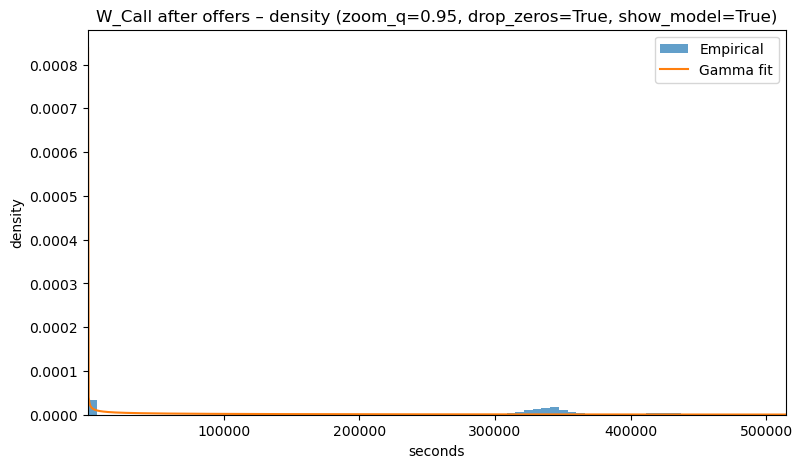

W_Complete application {'dist': 'lognorm', 'params': {'s': 2.7323964400391896, 'scale': 2216.115073396492}}
[np.float64(2424.6068789960623), np.float64(164680.61493539685), np.float64(140.4474616513019), np.float64(0.04470216209293507), np.float64(18866.194247138465), np.float64(62376.026306901374), np.float64(92.08845776420786), np.float64(1750.2754638975055), np.float64(296.99982924761247), np.float64(843.9204121036151)]


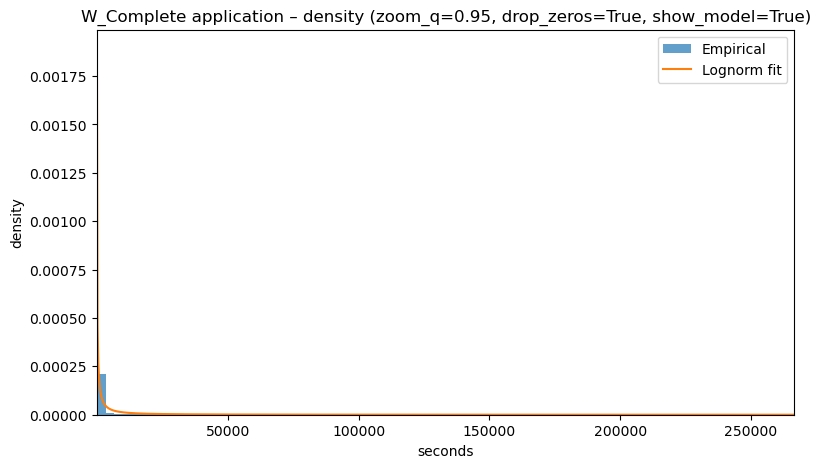

W_Validate application {'dist': 'lognorm', 'params': {'s': 3.6704630615702696, 'scale': 1523.3202469141893}}
[np.float64(33163.846148097386), np.float64(2537.3163764275732), np.float64(597.962822385628), np.float64(1.1599723475007317), np.float64(14734.687016235748), np.float64(2134.1303226396694), np.float64(54686.33012423557), np.float64(3232.41213273426), np.float64(15602.162612852531), np.float64(424189.7396643023)]


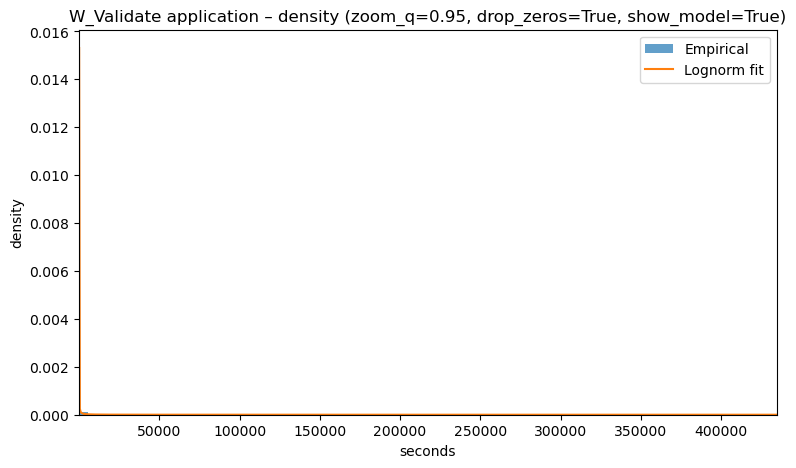

W_Call incomplete files {'dist': 'lognorm', 'params': {'s': 2.577493009427505, 'scale': 12028.501809386287}}
[np.float64(389.60594904797597), np.float64(2771.8044298561767), np.float64(103660.39357199526), np.float64(28093.375995145994), np.float64(6535063.289278987), np.float64(44930.4674041821), np.float64(646.0099733168466), np.float64(12432.920381487429), np.float64(5484.736886968874), np.float64(293.18952251628167)]


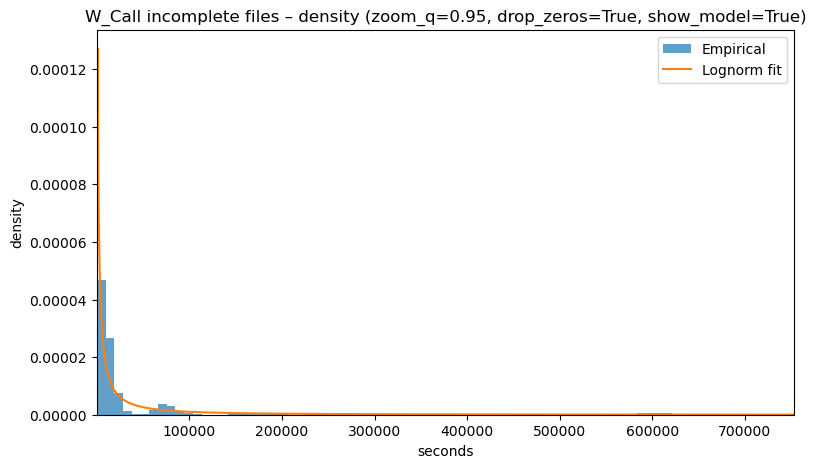

W_Handle leads {'dist': 'lognorm', 'params': {'s': 1.6431966377424219, 'scale': 117.70438233152178}}
[np.float64(146.1157640956321), np.float64(224.19004200472142), np.float64(10.302163206168807), np.float64(11.17092742378651), np.float64(54.73296572484579), np.float64(33.27860198377462), np.float64(43.35411669925628), np.float64(950.2169180752458), np.float64(28.034663278058638), np.float64(102.3882319818829)]


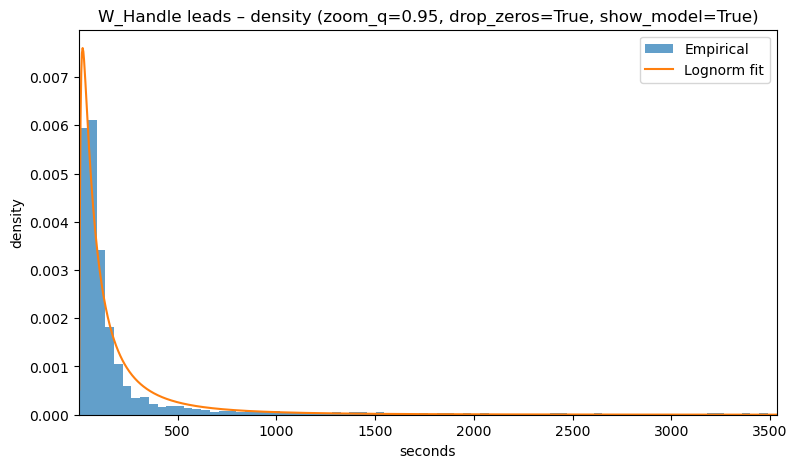

In [37]:
# --- Quick inspection / plots (optional) ---
# WARNING: plotting all activities can be slow.
# Choose which target you want to inspect:
which = "total"  # "proc" | "total" | "wait"
N = 5  # how many activities to inspect

if which == "proc":
    models = processing_models_proc
    durs = durations_full_proc
elif which == "total":
    models = processing_models_total
    durs = durations_full_total
elif which == "wait":
    models = processing_models_wait
    durs = durations_full_wait_pos
else:
    raise ValueError("which must be 'proc', 'total', or 'wait'")

for act in list(models.keys())[:N]:
    spec = models[act]
    print(act, spec)
    print(fk.sample_processing_time(spec, n=10))
    # For wait we fitted positive-part, so drop_zeros=True is correct
    fk.density_plot_from_counts(
        durs, act,
        show_model=(spec.get("dist") in {"gamma", "lognorm"}),
        dist=spec.get("dist", "gamma"),
        drop_zeros=True,
        zoom_q=0.95
    )


In [22]:
# --- Save models to separate JSON files (proc / total / wait) ---

with open("processing_models_proc.json", "w") as f:
    json.dump(processing_models_proc, f, indent=2)

with open("processing_models_total.json", "w") as f:
    json.dump(processing_models_total, f, indent=2)

with open("processing_models_wait.json", "w") as f:
    json.dump(processing_models_wait, f, indent=2)

# Optional bundle for convenience
bundle = {
    "meta": {
        "keys": ["case:concept:name", "concept:name", "instance"],
        "note": "wait is modeled as zero-inflated: p0 stored for fitted activities; const=0 for missing"
    },
    "proc": processing_models_proc,
    "total": processing_models_total,
    "wait": processing_models_wait
}
with open("processing_models_bundle.json", "w") as f:
    json.dump(bundle, f, indent=2)

# Backward compatibility: old code expects processing_models.json
with open("processing_models.json", "w") as f:
    json.dump(processing_models_proc, f, indent=2)

print("saved processing_models_proc.json / processing_models_total.json / processing_models_wait.json")
print("saved processing_models_bundle.json and processing_models.json (proc, for backward compatibility)")


saved processing_models_proc.json / processing_models_total.json / processing_models_wait.json
saved processing_models_bundle.json and processing_models.json (proc, for backward compatibility)


Point Estimator (maybe I need more features for this, ask in tut)

In [23]:


X = proc_inst[["concept:name"]].astype(str)
y = proc_inst["proc_seconds"].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y)

pipe = Pipeline([
    ("pre", ColumnTransformer([("cat", OneHotEncoder(handle_unknown="error"), ["concept:name"])])),
    ("model", RandomForestRegressor()),
])
pipe.fit(X_train, y_train)
print(mean_absolute_error(y_test, pipe.predict(X_test)))
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

pred = pipe.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2:", r2_score(y_test, pred))



670.2299106124365
RMSE: 2318.339922582949
R2: 0.03752692025707982


# Quantile Regression

In [24]:
from processing_times.quantile_regression import fit_and_eval_quantiles, baseline_empirical_by_activity
inst

,case:concept:name,concept:name,instance,proc_seconds,inst_start,inst_end,total_seconds,wait_seconds,occ_idx,occ_log,minute_of_day,tod_sin,tod_cos,weekday
0,Application_1000086665,W_Call after offers,0,129.277,2016-08-05 14:01:23.286000+00:00,2016-08-09 18:25:32.629000+00:00,361449.343,361320.066,0,0.0,841.0,-0.503774,-0.863836,4.0
1,Application_1000086665,W_Complete application,0,642.724,2016-08-04 13:39:29.557000+00:00,2016-08-04 13:50:12.281000+00:00,642.724,0.000,0,0.0,819.0,-0.418660,-0.908143,3.0
2,Application_1000158214,W_Call after offers,0,115.307,2016-06-06 08:16:46.890000+00:00,2016-06-06 08:18:42.197000+00:00,115.307,0.000,0,0.0,496.0,0.829038,-0.559193,0.0
3,Application_1000158214,W_Complete application,0,870.320,2016-06-06 08:02:16.549000+00:00,2016-06-06 08:16:46.869000+00:00,870.320,0.000,0,0.0,482.0,0.861629,-0.507538,0.0
4,Application_1000158214,W_Validate application,0,93.137,2016-06-09 09:54:35.628000+00:00,2016-06-09 09:56:08.765000+00:00,93.137,0.000,0,0.0,594.0,0.522499,-0.852640,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127081,Application_999993467,W_Validate application,0,2405.429,2016-07-13 14:26:03.551000+00:00,2016-07-19 11:03:45.120000+00:00,506261.569,503856.140,0,0.0,866.0,-0.594823,-0.803857,2.0
127082,Application_999993812,W_Call after offers,0,61.874,2016-10-10 12:47:12.423000+00:00,2016-10-14 08:18:57.232000+00:00,329504.809,329442.935,0,0.0,767.0,-0.203642,-0.979045,0.0
127083,Application_999993812,W_Call incomplete files,0,156.698,2016-10-19 12:44:29.291000+00:00,2016-10-20 08:21:59.667000+00:00,70650.376,70493.678,0,0.0,764.0,-0.190809,-0.981627,2.0
127084,Application_999993812,W_Complete application,0,447.742,2016-10-07 09:38:21.802000+00:00,2016-10-07 09:45:49.544000+00:00,447.742,0.000,0,0.0,578.0,0.580703,-0.814116,4.0


In [25]:
proc = inst

### A) Quantile Regression for **processing time** (`proc_seconds`)

In [26]:

cat_cols = ["concept:name"]
num_cols = ["tod_sin", "tod_cos", "instance", "weekday"]

res_proc = fit_and_eval_quantiles(proc, target="proc_seconds", cat_cols=cat_cols, num_cols=num_cols)

# baseline (empirical by activity)
baseline_empirical_by_activity(
    res_proc["X_train"], res_proc["y_train"], res_proc["X_test"], res_proc["y_test"], act_col="concept:name"
)


Coverage [q10,q90] (target ~0.80): 0.8002203163112754
Avg interval width (sec): 1218.216414097648
Pinball loss q10/q50/q90: 63.766223782619875 265.61192701590153 285.06968907487743
BASELINE Coverage [q10,q90]: 0.8017940042489574
BASELINE Avg width: 1259.2393226453694
BASELINE Pinball q10/q50/q90: 64.4964442194508 268.43317645959553 289.80272248524665


{'qs': (0.1, 0.5, 0.9),
 'coverage': 0.8017940042489574,
 'avg_width': 1259.2393226453694,
 'pin10': 64.4964442194508,
 'pin50': 268.43317645959553,
 'pin90': 289.80272248524665}

### B) Quantile Regression for **waiting/idle time** (`wait_seconds`)

In [27]:
res_wait = fit_and_eval_quantiles(proc, "wait_seconds", cat_cols, num_cols, qs=(0.10,0.50,0.90))
base_wait = baseline_empirical_by_activity(res_wait["X_train"], res_wait["y_train"],
                                           res_wait["X_test"], res_wait["y_test"],
                                           act_col="concept:name", qs=(0.10,0.50,0.90))


Coverage [q10,q90] (target ~0.80): 0.9037296404123062
Avg interval width (sec): 299064.724418385
Pinball loss q10/q50/q90: 14333.254790176255 45703.24374979067 47673.09103424694
BASELINE Coverage [q10,q90]: 0.8844519631757023
BASELINE Avg width: 328001.7401920135
BASELINE Pinball q10/q50/q90: 14332.948178857503 46958.83646374616 50212.874295619644
